In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

df = pd.read_csv("data/egx/ABUK.csv")

df.head()

,date,open,high,low,close,volume
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0


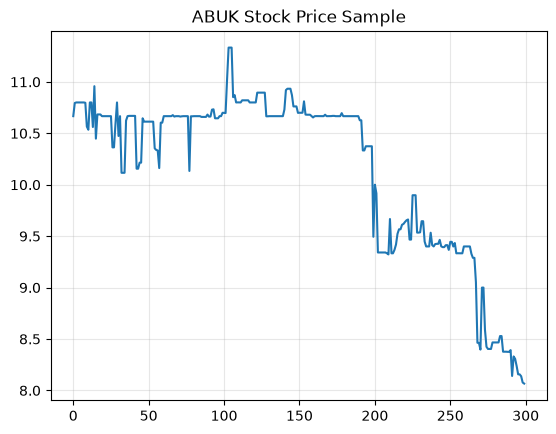

In [ ]:
series = df['close'].values.astype('float32')

plt.plot(series[:300])
plt.title("ABUK Stock Price Sample")
plt.grid(alpha=0.3)
plt.show()

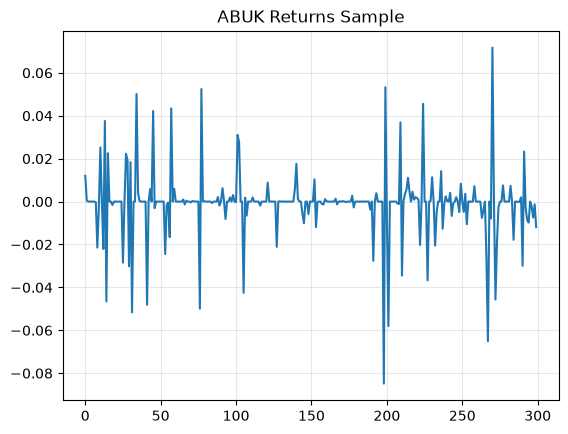

In [30]:
# نحول لـ returns بدل price (ده الصح في ML للstocks)
series = np.diff(series) / series[:-1]

plt.plot(series[:300])
plt.title("ABUK Returns Sample")
plt.grid(alpha=0.3)
plt.show()

In [31]:
seq_len = 10

Xs, ys = [], []

for i in range(seq_len, len(series) - 1):
    Xs.append(series[i-seq_len:i])
    ys.append(series[i])

Xs = np.array(Xs, dtype='float32').reshape(-1, seq_len, 1)
ys = np.array(ys, dtype='float32')

In [32]:
split = int(len(Xs) * 0.7)

Xtr = torch.tensor(Xs[:split])
ytr = torch.tensor(ys[:split])

Xte = torch.tensor(Xs[split:])
yte = torch.tensor(ys[split:])

In [33]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

In [34]:
train_hist, test_hist = [], []

for epoch in range(300):
    model.train()
    optimizer.zero_grad()

    pred = model(Xtr)
    loss = nn.functional.mse_loss(pred, ytr)

    loss.backward()
    optimizer.step()

    train_hist.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_loss = nn.functional.mse_loss(model(Xte), yte).item()
        test_hist.append(test_loss)

print(f"Final Test Loss: {test_hist[-1]:.6f}")

Final Test Loss: 0.000678


In [35]:
baseline = nn.functional.mse_loss(Xte[:, -1, 0], yte).item()

print(f'Baseline (no change): {baseline:.6f}')
print(f'LSTM improvement: {baseline/test_hist[-1]:.2f}x better')

Baseline (no change): 0.001312
LSTM improvement: 1.93x better


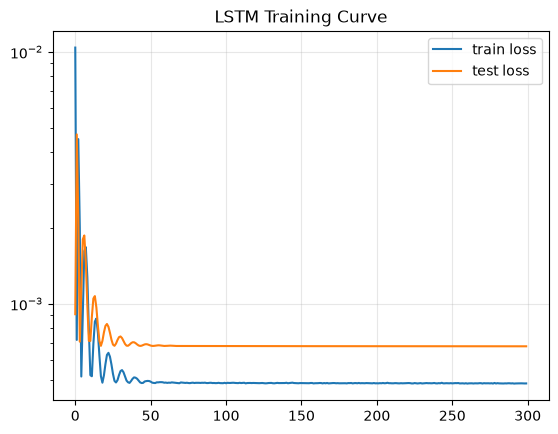

In [36]:
plt.plot(train_hist, label='train loss')
plt.plot(test_hist, label='test loss')

plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.title("LSTM Training Curve")

plt.show()

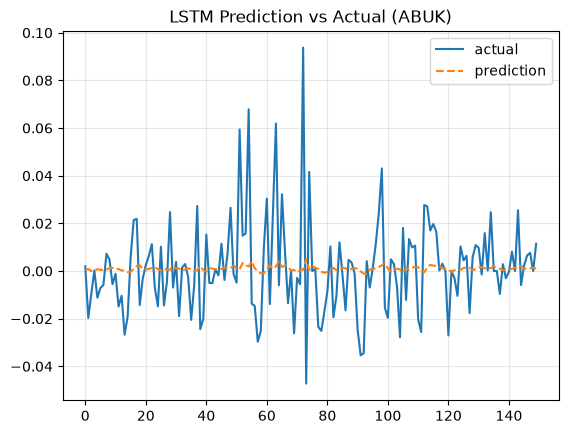

In [37]:
with torch.no_grad():
    preds = model(Xte).numpy()

show_n = 150

plt.plot(yte[:show_n], label='actual', linewidth=1.5)
plt.plot(preds[:show_n], '--', label='prediction', linewidth=1.5)

plt.legend()
plt.grid(alpha=0.3)
plt.title("LSTM Prediction vs Actual (ABUK)")

plt.show()

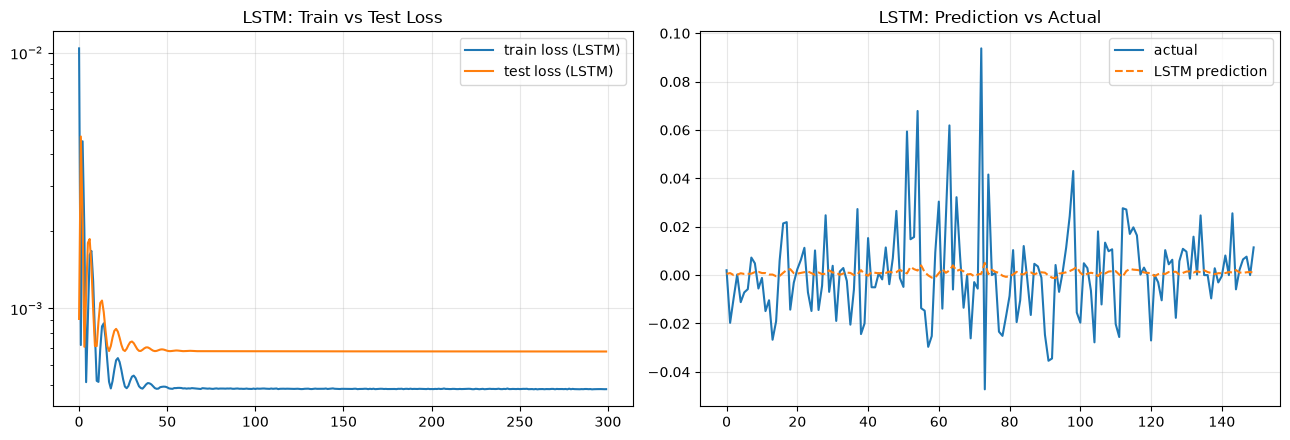

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# loss
axes[0].plot(train_hist, label='train loss (LSTM)')
axes[0].plot(test_hist, label='test loss (LSTM)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=.3)
axes[0].set_title("LSTM: Train vs Test Loss")

# prediction
with torch.no_grad():
    pred_test = model(Xte).numpy()

axes[1].plot(yte[:150], label='actual', linewidth=1.5)
axes[1].plot(pred_test[:150], '--', label='LSTM prediction', linewidth=1.5)

axes[1].legend()
axes[1].grid(alpha=.3)
axes[1].set_title("LSTM: Prediction vs Actual")

plt.tight_layout()
plt.show()

In [39]:
mlp_test_loss = 0.01402  # حط القيمة بتاعتك

print("=== COMPARISON: Day1 MLP vs LSTM ===")

print(f"MLP test loss (Day1): {mlp_test_loss:.6f}")
print(f"LSTM test loss:       {test_hist[-1]:.6f}")

ratio = mlp_test_loss / test_hist[-1]

if ratio > 1:
    print(f"✅ LSTM beat MLP by {ratio:.2f}x")
else:
    print(f"⚠️ MLP is better by {1/ratio:.2f}x")

=== COMPARISON: Day1 MLP vs LSTM ===
MLP test loss (Day1): 0.014020
LSTM test loss:       0.000678
✅ LSTM beat MLP by 20.67x


final train loss: 0.19919
final test loss:  3.48858
"just predict no change" loss: 3.37607


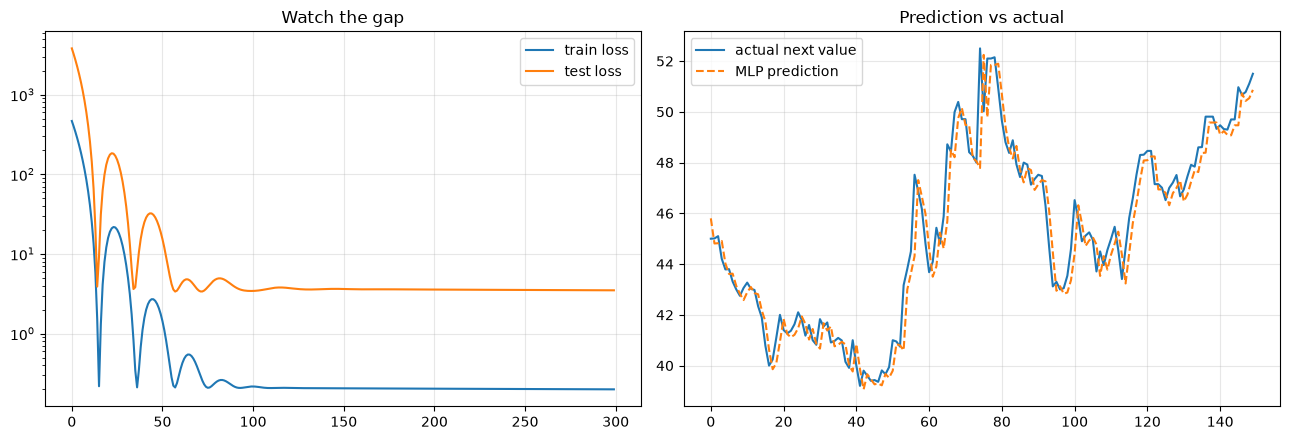

In [48]:
import sys, os

while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# load data
df = pd.read_csv('data/egx/ABUK.csv')

# استخدم عمود السعر (غير الاسم لو مختلف)
prices = df['close'].values.astype('float32')

# نحوله ل time series
series = prices
X = series[:-1].reshape(-1, 1).astype('float32')
y = series[1:].astype('float32')

# split زمني (مهم جدًا)
split = int(len(X) * 0.7)

Xtr, ytr = torch.tensor(X[:split]), torch.tensor(y[:split])
Xte, yte = torch.tensor(X[split:]), torch.tensor(y[split:])
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = MLP()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
train_hist, test_hist_mlp = [], []

for epoch in range(300):
    opt.zero_grad()
    
    loss = nn.functional.mse_loss(model(Xtr), ytr)
    loss.backward()
    opt.step()
    
    train_hist.append(loss.item())
    test_hist_mlp.append(
        nn.functional.mse_loss(model(Xte), yte).item()
    )
    # baseline: predict tomorrow = today
persistence_loss = nn.functional.mse_loss(
    Xte.squeeze(-1), yte
).item()

print(f'final train loss: {train_hist[-1]:.5f}')
print(f'final test loss:  {test_hist_mlp[-1]:.5f}')
print(f'"just predict no change" loss: {persistence_loss:.5f}')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# loss curves
axes[0].plot(train_hist, label='train loss')
axes[0].plot(test_hist_mlp, label='test loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=.3)
axes[0].set_title('Watch the gap')

# predictions
with torch.no_grad():
    pred_test = model(Xte).numpy()

show_n = 150

axes[1].plot(y[split:split+show_n], label='actual next value', linewidth=1.5)
axes[1].plot(pred_test[:show_n], label='MLP prediction', linewidth=1.5, linestyle='--')

axes[1].legend()
axes[1].grid(alpha=.3)
axes[1].set_title('Prediction vs actual')

plt.tight_layout()

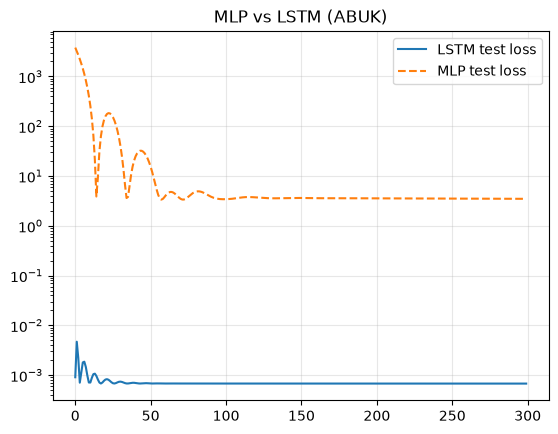

In [53]:
plt.plot(test_hist, label='LSTM test loss')
plt.plot(test_hist_mlp, linestyle='--', label='MLP test loss')

plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.title("MLP vs LSTM (ABUK)")

plt.show()

In [41]:
with torch.no_grad():
    preds = model(Xte).numpy()

# إشارات التداول
signals = np.where(preds > 0, 1, -1)  # 1 = buy, -1 = sell

# العائد الحقيقي
actual_returns = yte.numpy()

signals[:10], actual_returns[:10]

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([ 0.00199956, -0.01973391, -0.00950007,  0.00022832, -0.01118717,
        -0.00715773, -0.00581395,  0.00725149,  0.00487689, -0.00554661],
       dtype=float32))

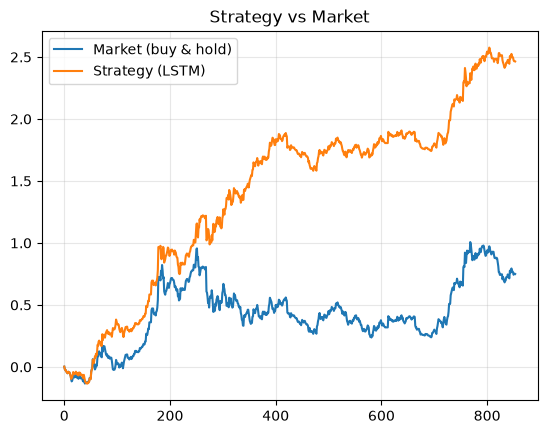

In [42]:
# العائد الاستراتيجي = الإشارة × العائد الحقيقي
strategy_returns = signals * actual_returns

# cumulative return
cum_strategy = np.cumsum(strategy_returns)
cum_market = np.cumsum(actual_returns)

plt.plot(cum_market, label='Market (buy & hold)')
plt.plot(cum_strategy, label='Strategy (LSTM)')

plt.legend()
plt.grid(alpha=0.3)
plt.title("Strategy vs Market")

plt.show()

In [43]:
print("=== Strategy Performance ===")

print(f"Mean return: {strategy_returns.mean():.6f}")
print(f"Std:         {strategy_returns.std():.6f}")

sharpe = strategy_returns.mean() / (strategy_returns.std() + 1e-8)
print(f"Sharpe ratio: {sharpe:.3f}")

accuracy = (np.sign(preds) == np.sign(actual_returns)).mean()
print(f"Direction accuracy: {accuracy:.2%}")

=== Strategy Performance ===
Mean return: 0.002886
Std:         0.025946
Sharpe ratio: 0.111
Direction accuracy: 48.48%
